# Train / validation split

**Reads:** `data/<DATASET>/manifest/`, `configs/` · **Role:** the *only* writer of `data/<DATASET>/split/`.

This notebook turns the audit's measurements and the human rulings into one decision per image:
which label it carries, whether it is used, and which side of the split it lands on.

### Decisions this applies (made elsewhere, recorded in `configs/`)

- **Split by filename group.** The `{prefix}_{number}` part of each filename stays on one side.
  The persisted field is named `writer_id`, but the dataset provides no evidence that it identifies a
  person. The `sg`/`tg` suffix is likewise stored as `session` but has no verified meaning.
  Validation measures held-out filename groups, not unseen handwriting or a known hidden-test distribution.
- **Train / val only.** The real test set is held by the instructor. Nothing here is called "test",
  and val is used for model selection, so its score is optimistic by construction.
- **Tiny classes train only.** A class with fewer than `min_val_class_images` distinct images can't be
  validated. It is trained on and flagged *not validated*, never silently dropped.
- Labels come from `cross_class_rulings.csv` and the optional `image_rulings.csv`; what is still
  contradictory is handled by `unruled_cross_class` in `configs/split.json`.

### Ground rules

- `raw/` and `manifest/` are read-only.
- Deterministic: seeded search, sorted order, and the filename-group assignment is **frozen** in
  `split/writers.csv` until `configs/split.json` changes — new rulings move images, never whole groups.

## 1 · Load

In [1]:
import json
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thai_char_cnn import labels, split
from thai_char_cnn.paths import CONFIGS, DATASET, MANIFEST, RAW, ROOT, SPLIT_DIR

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
CHECKS = []

def check(name: str, ok: bool, detail: str = ""):
    CHECKS.append(dict(check=name, passed=bool(ok), detail=detail))
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f"  — {detail}" if detail else ""))

def raw_signature() -> dict:
    st = [p.stat() for p in RAW.rglob("*") if p.is_file()]
    return dict(n=len(st), bytes=sum(s.st_size for s in st), mtime=max(s.st_mtime_ns for s in st))

sig0 = raw_signature()
manifest = pd.read_csv(MANIFEST / "images.csv", keep_default_na=False, na_values=[""])
filename_parts = manifest.file_name.str.extract(r"^(?:Copy of )?(?P<writer_id>[a-z]+_\d+)(?P<session>sg|tg)_\d+_\d+\.[A-Za-z]+$")
assert filename_parts.notna().all().all(), "every manifest filename must identify its filename group and tag"
manifest = manifest.join(filename_parts)
cfg = split.load_split_config(CONFIGS / "split.json")
class_idx = split.class_index(MANIFEST / "classes.csv")
char = (pd.read_csv(CONFIGS / "class_labels.csv", keep_default_na=False)
        .set_index("class_folder").character.to_dict())

print(f"dataset   : {DATASET}")
print(f"manifest  : {len(manifest):,} images, {manifest.writer_id.nunique()} filename groups, {len(class_idx)} classes")
print(f"split cfg : {cfg}")
print(f"rulings   : cross_class_rulings.csv={'yes' if (CONFIGS / 'cross_class_rulings.csv').exists() else 'no'}  "
      f"image_rulings.csv={'yes' if (CONFIGS / 'image_rulings.csv').exists() else 'no'}")

dataset   : baseline
manifest  : 62,707 images, 52 filename groups, 72 classes
split cfg : {'unit': 'writer', 'val_fraction': 0.2, 'min_val_class_images': 20, 'seed': 42, 'search_iters': 5000, 'unruled_cross_class': 'drop'}
rulings   : cross_class_rulings.csv=yes  image_rulings.csv=yes


## 2 · Apply rulings

**What:** one label per image, and an exclusion reason for images that can't be used yet.
Image rulings win over group rulings; anything in a near-duplicate group that still carries two
labels afterwards, and has no ruling of its own, falls to the `unruled_cross_class` policy.

**Why here:** the labels a model sees must be the same in every notebook that reads the split, so
they are decided once and written down, not recomputed by each consumer.

**What this does not claim:** an exclusion is not a verdict that the image is wrong. `hold` and
unruled images are waiting on `02_visual_check.py`; once ruled, they come back on the next run.

In [2]:
ruled = labels.apply_rulings(manifest, CONFIGS, cfg["unruled_cross_class"])
df = ruled.join(manifest[["writer_id", "session", "sha_group_id", "near_dup_group_id"]])
df["class_idx"] = df.label_class.map(class_idx)

print(f"included          : {int(df.included.sum()):,} / {len(df):,}")
print(f"relabelled        : {int((df.label_class != df.orig_class).sum())}")
print("\nexclusions by reason:")
excl = (df[~df.included].groupby(["exclude_reason", "ruling_source"])
        .agg(images=("path", "size"), classes=("orig_class", lambda s: ",".join(map(str, sorted(s.unique()))))))
excl if len(excl) else print("  none")

included          : 62,480 / 62,707
relabelled        : 0

exclusions by reason:


,,images,classes
exclude_reason,ruling_source,,
cross_class_hold,cross_class_rulings,4,"210,229"
image_ruling_drop,image_rulings,184,"161,164,168,183,186,187,190,194,195,197,199,20..."
unruled_cross_class,policy:unruled_cross_class,39,"210,229"


## 3 · Filename-group inventory

**What:** how much each filename group contributed, and how many classes it covers.

**Why:** the split unit's size distribution bounds how finely the val fraction can be hit. A few
filename groups hold thousands of images each, so val is assembled from whole groups and lands *near*
20%, not on it.

filename groups       : 52
images per group      : 24-2785  (median 1174)
classes per group     : 10-51  (median 40)
largest group         : 2,785 images = 4.5% of the corpus


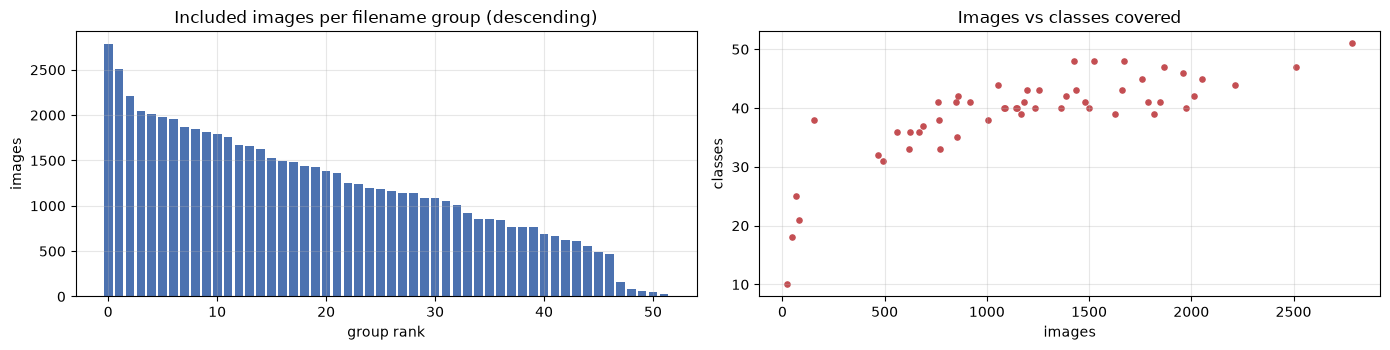

In [3]:
inv = (df[df.included].groupby("writer_id")
       .agg(images=("path", "size"), classes=("label_class", "nunique"), sessions=("session", "nunique"))
       .sort_values("images", ascending=False))
print(f"filename groups       : {len(inv)}")
print(f"images per group      : {inv.images.min()}-{inv.images.max()}  (median {inv.images.median():.0f})")
print(f"classes per group     : {inv.classes.min()}-{inv.classes.max()}  (median {inv.classes.median():.0f})")
print(f"largest group         : {inv.images.iloc[0]:,} images = {inv.images.iloc[0] / inv.images.sum():.1%} of the corpus")

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].bar(range(len(inv)), inv.images, color="#4C72B0")
ax[0].set(title="Included images per filename group (descending)", xlabel="group rank", ylabel="images")
ax[1].scatter(inv.images, inv.classes, s=14, color="#C44E52")
ax[1].set(title="Images vs classes covered", xlabel="images", ylabel="classes")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4 · Filename-group assignment

**What:** choose the val filename groups. A seeded random search tries `search_iters` group orders, fills
val greedily from each to about `val_fraction` of the images, and keeps the order whose per-class val
share is closest to that fraction on average. An eligible class with no val image at all is
penalised heavily.

**Frozen:** the result is saved in `split/writers.csv` with a hash of the split config and reused
while that hash matches. Rulings that arrive later change which *images* are used, never which
*filename groups* are in val, so earlier runs stay comparable group-for-group.

**What this does not claim:** the search finds a good assignment, not the optimal one. Balance is
measured on images, not on a known source, writer, font, or hidden-test factor.

In [4]:
tiny = split.tiny_classes(df, cfg)
prev_run = json.loads((SPLIT_DIR / "run.json").read_text(encoding="utf-8")) if (SPLIT_DIR / "run.json").exists() else {}
writers, search = split.load_or_assign_writers(df, cfg, SPLIT_DIR / "writers.csv")
if search["reused"]:
    search = prev_run.get("writer_search", {}) | dict(reused=True)
    print(f"reused frozen filename-group assignment ({SPLIT_DIR.relative_to(ROOT)}/writers.csv, "
          f"config hash {split.config_hash(cfg)})")
else:
    print(f"built a new filename-group assignment ({cfg['search_iters']:,} orders searched)")
print(json.dumps(search, indent=2))

val_writers = writers[writers.split == "val"]
print(f"\nval filename groups ({len(val_writers)}): {', '.join(val_writers.writer_id)}")

reused frozen filename-group assignment (data\baseline\split/writers.csv, config hash 21659d2db95e)
{
  "score": 0.04347,
  "val_writers": 9,
  "val_share_of_eligible": 0.1972,
  "per_class_share_min": 0.0769,
  "per_class_share_max": 0.4136,
  "eligible_classes_without_val": 0,
  "tiny_classes": [
    163,
    177,
    196,
    204,
    206,
    214,
    244,
    245,
    246,
    247,
    249
  ],
  "reused": true
}

val filename groups (9): bc_001, bc_009, bc_013, bc_020, be_002, be_006, be_016, be_018, bl_004


## 5 · Per-class support

**What:** train / val images per class after the filename-group split, counted **once per (SHA, label, split)**:
byte-identical copies (class 229 holds one image 88 times) count once on each side.

**Status flags:**

| status | meaning |
| --- | --- |
| `validated` | enough val images to measure; counted in the headline macro-F1 |
| `weak` | has val images, but fewer than 5 — its F1 is noise |
| `not_validated` | tiny class, all images in train; nothing measures it |

**What this does not claim:** a validated class is measurable, not well-measured. With only a
handful of val filename groups, a class's val set can be one or two groups only.

In [5]:
df = split.dedup_within_split(split.assign_images(df, writers, tiny))
canon = df[df.is_split_canonical]
counts = canon.groupby(["label_class", "split"]).size().unstack(fill_value=0).reindex(columns=["train", "val"], fill_value=0)

classes = pd.DataFrame({"folder": list(class_idx)}, index=pd.Index(list(class_idx.values()), name="class_idx"))
classes["character"] = classes.folder.map(char).fillna("")
classes["train_n"] = classes.folder.map(counts.train).fillna(0).astype(int)
classes["val_n"] = classes.folder.map(counts.val).fillna(0).astype(int)
classes["status"] = np.select(
    [(classes.train_n + classes.val_n) == 0, classes.folder.isin(tiny), classes.val_n < 5],
    ["empty", "not_validated", "weak"], "validated")
classes["val_share"] = (classes.val_n / (classes.train_n + classes.val_n)).round(3)
classes = classes.reset_index()

print(classes.status.value_counts().to_string())
print(f"\nimages forced to train (tiny class, val filename group): {int(df.forced_train.sum())}")
print(f"val share over validated classes: {classes.query('status == \"validated\"').val_share.describe()[['min', '50%', 'max']].round(3).to_dict()}")
print("\nnot validated / weak:")
classes[classes.status != "validated"]

status
validated        56
not_validated    11
weak              5

images forced to train (tiny class, val filename group): 27
val share over validated classes: {'min': 0.097, '50%': 0.196, 'max': 0.411}

not validated / weak:


,class_idx,folder,character,train_n,val_n,status,val_share
2,2,163,ฃ,1,0,not_validated,0.000
12,12,177,ฑ,1,0,not_validated,0.000
24,24,189,ฝ,36,3,weak,0.077
31,31,196,ฤ,13,0,not_validated,0.000
38,38,204,ฬ,3,0,not_validated,0.000
40,40,206,ฮ,10,0,not_validated,0.000
41,41,207,ฯ,16,4,weak,0.200
46,46,214,ึ,14,0,not_validated,0.000
51,51,225,แ,19,2,weak,0.095
60,60,234,๊,45,4,weak,0.082


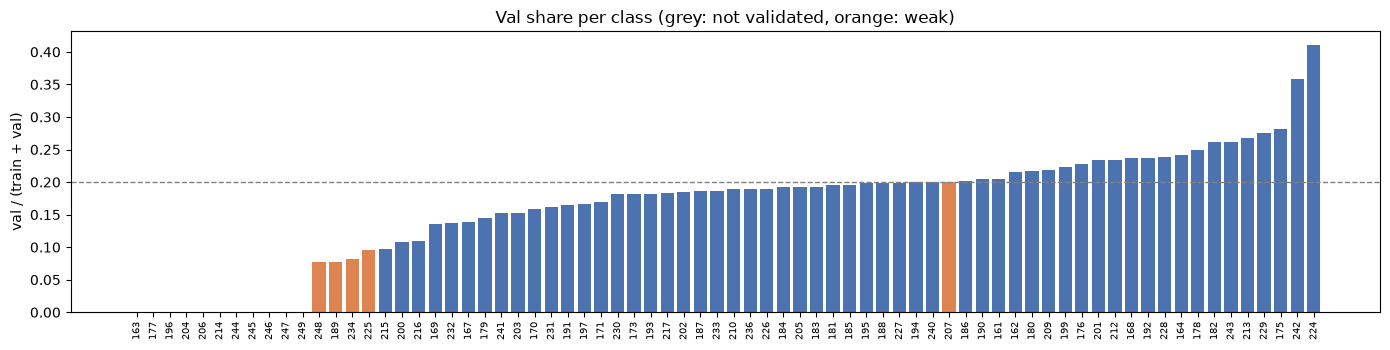

In [6]:
o = classes[classes.status != "empty"].sort_values("val_share")
colors = o.status.map({"validated": "#4C72B0", "weak": "#DD8452", "not_validated": "#8C8C8C"})
fig, ax = plt.subplots(figsize=(14, 3.6))
ax.bar(o.folder.astype(str), o.val_share, color=colors)
ax.axhline(cfg["val_fraction"], ls="--", c="gray", lw=1)
ax.set(title="Val share per class (grey: not validated, orange: weak)", ylabel="val / (train + val)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 6 · Cross-split twins

**What:** val images whose exact bytes also appear in train, and near-duplicate groups that end up
on both sides.

**Why only reported:** 1,000 byte-identical SHA groups span filename groups. Their source relationship
is unknown. Forcing each group onto one side would chain 37 of 52 filename groups into a single block
and leave no useful group split. So filename-group purity is enforced and this possible leakage is
measured.

**What this does not claim:** a twin identifies identical pixels, not its origin or generation process.
It can inflate val on the listed classes; it does not by itself establish whether the split is a good
proxy for the hidden test set.

In [7]:
tr = canon[canon.split == "train"]
va = canon[canon.split == "val"]
twin_same = va.set_index(["sha_group_id", "label_class"]).index.isin(tr.set_index(["sha_group_id", "label_class"]).index)
twin_any = va.sha_group_id.isin(tr.sha_group_id)
nd_split = canon.groupby("near_dup_group_id").split.nunique()

print(f"val images                                : {len(va):,}")
print(f"  with an exact twin in train (same label): {int(twin_same.sum()):,}  ({twin_same.mean():.1%})")
print(f"  with an exact twin in train (any label) : {int(twin_any.sum()):,}")
print(f"near-dup groups on both sides             : {int((nd_split > 1).sum()):,}")
twins = (va[twin_same].groupby("label_class").size().rename("val_twins").to_frame()
         .join(va.groupby("label_class").size().rename("val_n")))
twins["share"] = (twins.val_twins / twins.val_n).round(3)
twins["character"] = twins.index.map(char)
print("\nclasses with the most val twins:")
twins.sort_values("val_twins", ascending=False).head(10)

val images                                : 11,996
  with an exact twin in train (same label): 466  (3.9%)
  with an exact twin in train (any label) : 466
near-dup groups on both sides             : 516

classes with the most val twins:


,val_twins,val_n,share,character
label_class,,,,
229,135,405,0.333,ๅ
209,109,820,0.133,ั
210,80,713,0.112,า
195,24,911,0.026,ร
199,22,483,0.046,ว
232,17,46,0.370,่
186,14,367,0.038,บ
236,13,131,0.099,์
185,9,949,0.009,น


## 7 · Write the split

| File | Contents |
| --- | --- |
| `writers.csv` | filename group (`writer_id`, retained as a schema name) → split, with the split-config hash it was built under |
| `images.csv` | one row per manifest image: label, class index, split, inclusion, why excluded, canonical-within-split flag |
| `classes.csv` | the fixed 72-class index, train/val support and status |
| `run.json` | `split_id`, config, counts, search summary, self-checks |

`split_id` hashes the split config, the filename-group assignment and every image's (label, split,
inclusion, canonical) — so it changes exactly when what a model would train or be scored on changes.
Training runs record it, and `04_train.ipynb` ranks only runs on the current `split_id`.

In [8]:
IMAGE_COLS = ["path", "writer_id", "orig_class", "label_class", "class_idx", "split", "included",
              "exclude_reason", "ruling_source", "forced_train", "is_split_canonical", "sha_group_id"]
CLASS_COLS = ["class_idx", "folder", "character", "train_n", "val_n", "status"]
images_out = df[IMAGE_COLS].sort_values("path").reset_index(drop=True)
classes_out = classes[CLASS_COLS]
writers_out = writers[["writer_id", "split", "n_images", "n_classes", "config_hash"]]

def split_id_of(images_out: pd.DataFrame, writers_out: pd.DataFrame) -> str:
    key_cols = ["path", "label_class", "split", "included", "is_split_canonical"]
    return split.stable_hash(dict(config=split.config_hash(cfg), policy=cfg["unruled_cross_class"],
                                  writers=writers_out[["writer_id", "split"]].to_csv(index=False),
                                  images=images_out[key_cols].to_csv(index=False)))

SPLIT_ID = split_id_of(images_out, writers_out)
writers_out.to_csv(SPLIT_DIR / "writers.csv", index=False)
images_out.to_csv(SPLIT_DIR / "images.csv", index=False)
classes_out.to_csv(SPLIT_DIR / "classes.csv", index=False)
print(f"split_id: {SPLIT_ID}\n")
for f in sorted(SPLIT_DIR.glob("*.csv")):
    print(f"  {f.relative_to(ROOT).as_posix():40} {f.stat().st_size / 1e6:6.2f} MB")

split_id: 50c201baf3b1

  data/baseline/split/classes.csv            0.00 MB
  data/baseline/split/images.csv             4.47 MB
  data/baseline/split/writers.csv            0.00 MB


## 8 · Self-check

Checks this notebook's own bookkeeping. Whether val is a *good* proxy for the hidden test set is
not something arithmetic can answer.

In [9]:
inc = images_out[images_out.included]
back = pd.read_csv(SPLIT_DIR / "images.csv", keep_default_na=False)
wback = pd.read_csv(SPLIT_DIR / "writers.csv")
wsplit = inc.writer_id.map(writers_out.set_index("writer_id").split)
impure = inc[inc.split != wsplit]

check("every manifest row appears once", len(images_out) == len(manifest) and images_out.path.is_unique
      and set(images_out.path) == set(manifest.path))
check("every included row has a split", bool(inc.split.isin(["train", "val"]).all()))
check("excluded rows have no split and a reason",
      bool((images_out[~images_out.included].split == "").all()
           and (images_out[~images_out.included].exclude_reason != "").all()))
check("filename-group purity holds except counted tiny-class images",
      len(impure) == int(images_out.forced_train.sum()) and bool(impure.label_class.isin(tiny).all()),
      f"{len(impure)} tiny-class images moved to train")
check("class_idx covers the audit's folders, 0..C-1",
      sorted(classes_out.class_idx) == list(range(len(class_idx)))
      and set(classes_out.folder) == set(pd.read_csv(MANIFEST / "classes.csv").class_folder))
check("every included label is a known class", bool(inc.class_idx.notna().all()))
check("no class is val-only", int(((classes_out.val_n > 0) & (classes_out.train_n == 0)).sum()) == 0)
check("tiny classes have no val images", int(classes_out[classes_out.status == "not_validated"].val_n.sum()) == 0)
check("one canonical row per (sha, label, split)",
      int(inc.is_split_canonical.sum()) == len(inc.drop_duplicates(["sha_group_id", "label_class", "split"])))
check("class counts match canonical rows",
      int(classes_out.train_n.sum() + classes_out.val_n.sum()) == int(inc.is_split_canonical.sum()))
check("filename-group search is deterministic",
      split.assign_writers(df, cfg)[0].equals(split.assign_writers(df, cfg)[0]))
check("split_id reproduces from the written files", split_id_of(back, wback) == SPLIT_ID)
check("raw/ untouched", raw_signature() == sig0)

gate = pd.DataFrame(CHECKS)
run = dict(
    dataset=DATASET, split_id=SPLIT_ID,
    generated_at=datetime.now(UTC).isoformat(timespec="seconds"),
    config=cfg, config_hash=split.config_hash(cfg), writer_search=search,
    counts=dict(manifest_images=len(manifest), included=int(images_out.included.sum()),
                excluded=int((~images_out.included).sum()),
                excluded_by_reason=images_out[~images_out.included].exclude_reason.value_counts().to_dict(),
                relabelled=int((images_out.label_class != images_out.orig_class).sum()),
                writers=len(writers_out), val_writers=int((writers_out.split == "val").sum()),
                train_images=int(classes_out.train_n.sum()), val_images=int(classes_out.val_n.sum()),
                forced_train=int(images_out.forced_train.sum()),
                val_exact_twins_in_train=int(twin_same.sum()),
                classes=len(classes_out), classes_by_status=classes_out.status.value_counts().to_dict()),
    not_validated=classes_out[classes_out.status == "not_validated"].folder.tolist(),
    weak=classes_out[classes_out.status == "weak"].folder.tolist(),
    checks={c["check"]: ("PASS" if c["passed"] else "FAIL") for c in CHECKS},
)
(SPLIT_DIR / "run.json").write_text(json.dumps(run, indent=2, ensure_ascii=False), encoding="utf-8")

n_ok = int(gate.passed.sum())
print(f"\n{n_ok}/{len(gate)} checks passed")
if n_ok != len(gate):
    display(gate[~gate.passed])
print(f"\nsplit {SPLIT_ID} written to {SPLIT_DIR.relative_to(ROOT)}")
print("Next: uv run jupyter lab notebooks/04_train.ipynb")

  [PASS] every manifest row appears once
  [PASS] every included row has a split
  [PASS] excluded rows have no split and a reason
  [PASS] filename-group purity holds except counted tiny-class images  — 27 tiny-class images moved to train
  [PASS] class_idx covers the audit's folders, 0..C-1
  [PASS] every included label is a known class
  [PASS] no class is val-only
  [PASS] tiny classes have no val images
  [PASS] one canonical row per (sha, label, split)
  [PASS] class counts match canonical rows
  [PASS] filename-group search is deterministic
  [PASS] split_id reproduces from the written files
  [PASS] raw/ untouched

13/13 checks passed

split 50c201baf3b1 written to data\baseline\split
Next: uv run jupyter lab notebooks/04_train.ipynb
